In [6]:
import requests
import pandas as pd
from dotenv import load_dotenv
import os

load_dotenv()
API_KEY = os.getenv("API_KEY")

cities = ["Delhi", "Mumbai", "Bangalore", "Kolkata", "Tokyo", "Haryana","punjab"]

weather_data = []

for city in cities:
    url = f"http://api.openweathermap.org/data/2.5/weather?q={city}&appid={API_KEY}&units=metric"
    response = requests.get(url).json()
    
    if response.get("cod") != 200:
        print(f"Error for {city}: {response.get('message')}")
        continue
    
    weather_data.append({
        "city": city,
        "temperature": response["main"]["temp"],
        "humidity": response["main"]["humidity"],
        "wind_speed": response["wind"]["speed"],
        "pressure": response["main"]["pressure"]
    })

weather_df = pd.DataFrame(weather_data)
print(weather_df)

        city  temperature  humidity  wind_speed  pressure
0      Delhi        23.05        49        1.03      1007
1     Mumbai        26.99        83        0.00      1008
2  Bangalore        24.61        71        4.92      1010
3    Kolkata        25.97        94        3.60      1007
4      Tokyo        15.63        47        6.69      1013
5    Haryana        22.38        39        1.12      1008
6     punjab        20.83        46        2.32      1009


In [7]:
token = os.getenv("TOKEN")
aqi_data = []

for city in cities:
    url = f"https://api.waqi.info/feed/{city}/?token={token}"
    response = requests.get(url).json()
    
    if response["status"] == "ok":
        data = response["data"]

        aqi_data.append({
            "city": city,
            "aqi": data["aqi"],
            "pm25": data["iaqi"]["pm25"]["v"] if "pm25" in data["iaqi"] else None,
            "pm10": data["iaqi"]["pm10"]["v"] if "pm10" in data["iaqi"] else None
        })
    
    else:
        print(f"Error for {city}: {response['data']}")

aqi_df = pd.DataFrame(aqi_data)
aqi_df

Error for Haryana: Unknown station
Error for punjab: Unknown station


,city,aqi,pm25,pm10
0,Delhi,112,112,86
1,Mumbai,136,136,79
2,Bangalore,158,158,81
3,Kolkata,103,103,55
4,Tokyo,46,46,13


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   city         5 non-null      object 
 1   temperature  5 non-null      float64
 2   humidity     5 non-null      int64  
 3   wind_speed   5 non-null      float64
 4   pressure     5 non-null      int64  
 5   aqi          5 non-null      int64  
 6   pm25         5 non-null      int64  
 7   pm10         5 non-null      int64  
 8   timestamp    5 non-null      object 
dtypes: float64(2), int64(5), object(2)
memory usage: 492.0+ bytes
None


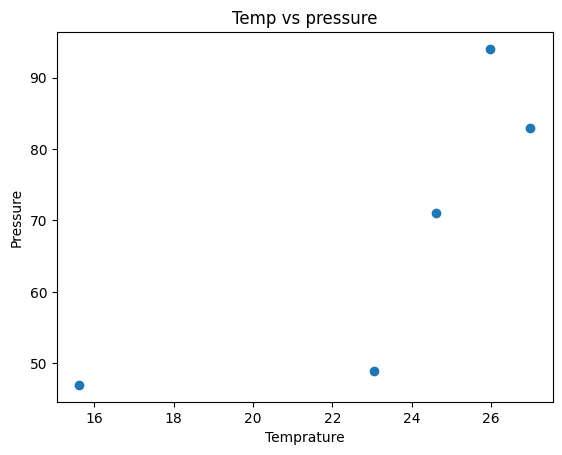

In [8]:
from datetime import datetime
import matplotlib.pyplot as plt
df = pd.merge(weather_df, aqi_df, on="city")
df["timestamp"] = datetime.now().strftime("%H:%M")

df.to_csv(r"D:\PROJECTS\Air_Watch\Data\raw.csv", index=False)
print(df.info())

# plt.figure(figsize=(10,5))
plt.scatter(df['temperature'],df['humidity'])
plt.title("Temp vs pressure")
plt.xlabel("Temprature")
plt.ylabel("Pressure")
plt.show()


In [9]:
import sqlite3
conn = sqlite3.connect("D:/PROJECTS/Air_Watch/database/airwatch.db")
df.to_sql("air_quality", conn, if_exists="append", index=False)
conn.close()



In [10]:
conn = sqlite3.connect("D:/PROJECTS/Air_Watch/database/airwatch.db")
check_df = pd.read_sql("SELECT * FROM air_quality", conn)
check_df.head()

,city,temperature,humidity,wind_speed,pressure,aqi,pm25,pm10,timestamp
0,Delhi,26.05,61,3.60,1012,153,153,101,11:02
1,Mumbai,30.99,51,3.09,1013,74,74,48,11:02
2,Bangalore,29.09,59,3.60,1012,109,109,61,11:02
3,Kolkata,33.97,52,3.09,1007,89,89,40,11:02
4,Tokyo,14.49,92,6.69,1013,57,57,17,11:02
